# Bayesian A/B Testing as a Decision Problem
### From prior beliefs to a business recommendation — worked two ways (grid integration & MCMC)

**Author: Felipe Oliveira Franco · Data‑Science Portfolio**

---

This notebook works a single problem *end to end*: we test a new product experience against a control, update our beliefs with the data, and turn the resulting posterior into an actual business decision.
The point is not just to get a number, it is to make every step transparent and to show that the **math** and the **computation** agree.

What it demonstrates:

| Theme | What you'll see |
|---|---|
| **Probabilistic modelling** | A logistic (GLM) parameterisation with `standard` + `novel` and Normal priors |
| **Bayes' theorem, explicitly** | The posterior written out term by term, with the Bernoulli/Binomial likelihood derived |
| **Two computational engines** | A deterministic **grid integration** and **MCMC with PyMC**, cross‑checked against each other |
| **Decision theory** | **Expected regret** — and an honest discussion of why regret is not the whole story |
| **Predictive planning** | A **posterior‑predictive** simulation of whether we hit next week's revenue target |

> **Note.** The scenario below is fictional but realistic; the numbers are chosen to illustrate the methods. The structure (a logistic A/B test with a regret analysis and a weekly target) is a standard pattern in Bayesian decision‑making.

**To run:** `numpy`, `scipy`, `matplotlib`, `pandas` for the core; `pymc` and `arviz` for the MCMC section. A global random seed is set for reproducibility.

---

## 1. The business problem

A company offers a subscription **service** with a **one‑month free trial**. At the end of the trial, the customer can sign up for the service for a **full year**. The team wants more trial users to take up the yearly service, so they build a new end‑of‑trial experience (**strategy B**) and test it against the current one (**strategy A**).

We assume the running cost of either experience is the same, and every conversion is worth the same expected **<span>$<span>1,200** (first‑year contract value).

**Model (chosen *before* the test).** A logistic regression (logit link function) with standard and novel parameters:

$$
\begin{aligned}
\text{standard } \alpha &\sim \mathrm{Normal}(\mu=-1.5,\ \sigma=0.2)\\
\text{novel } \beta &\sim \mathrm{Normal}(\mu=0.15,\ \sigma=0.5)\\[4pt]
\mathrm{logit}\,P(\text{convert}\mid \text{A, standard}) &= \alpha\\
\mathrm{logit}\,P(\text{convert}\mid \text{B, novel}) &= \alpha + \beta
\end{aligned}
$$

**The experiment.** 80 trial users per arm:

| arm | conversions | trials | observed rate |
|---|:---:|:---:|:---:|
| A  standard | 17 | 80 | 0.2125 |
| B  novel    | 20 | 80 | 0.2500 |

**The questions.**

- **(a)** What is the **prior** and **posterior** probability that strategy **B** is better?
- **(b)** Per subsequent trial, what is the prior and posterior **expected regret** of each branch
  (the expected cost of making the suboptimal choice)?
- **(c)** Given the data and our prior, **what should the company do?**
- **(d)** The team wants at least **<span>$</span>24,000** of new contract value per week, and typically sees
  about **100** trial completions per week. Stating any extra assumptions, what is the posterior
  probability of **missing** that target next week, for each branch?

---

Before beginning the analysis, we import the required libraries and define the key parameters, helper functions, priors, and experimental data used throughout the notebook.

In [76]:
# - Libraries -------------------------------------------------------
import numpy as np                     # arrays, RNG, vectorised math
import pandas as pd                    # tabular summaries (used later)
import matplotlib.pyplot as plt        # plotting
from scipy.stats import norm, binom    # Normal CDF for (a), Binomial PMF for (d)
import pymc as pm                      # Bayesian modelling and MCMC sampling
import arviz as az                     # posterior diagnostics and Bayesian summaries

# - Plotting and palette --------------------------------------------
PALETTE = {"A": "#0072B2", "B": "#D55E00", "prior": "#999999",
           "post": "#009E73", "accent": "#CC79A7"}
plt.rcParams.update({
    "figure.figsize": (15, 7),
    "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
})

# - Helper functions ------------------------------------------------
# Inverse logit (sigmoid): maps a log-odds value back to a probability.
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# - Reproducibility -------------------------------------------------
# Seeds NumPy's RNG (used for the posterior-predictive sim in part d).
seed = 7
rng = np.random.default_rng(seed)
print(f"Random seed set to {seed} for reproducibility.")

# - Priors (chosen by the analysts before the test) -----------------
# Both priors are on the log-odds (logit) scale.
MU_A, SD_A = -1.50, 0.2      # standard: baseline log-odds of conversion (arm A)
MU_B, SD_B =  0.15, 0.5      # novel lift: log-odds shift added by arm B
print(f"Standard parameter (A): Mean = {MU_A}, STD = {SD_A}")
print(f"Novel-lift parameter (B): Mean = {MU_B}, STD = {SD_B}")

# - Experiment data -------------------------------------------------
# Conversions (k) out of trial users (n) for each arm.
N_A, K_A = 80, 17            # control   A
N_B, K_B = 80, 20            # treatment B
print(f"Experiment results: A = {K_A}/{N_A} ({K_A/N_A:.4f}), B = {K_B}/{N_B} ({K_B/N_B:.4f})")

# - Business constants ----------------------------------------------
VALUE       = 1200           # $ value of one conversion (first-year contract)
WEEKLY_N    = 100            # expected trial completions per week
TARGET_REV  = 24_000         # weekly revenue target ($)
# Minimum conversions to hit the target: ceil(24000 / 1200) = 20.
# So "missing" the target means 19 or fewer conversions.
TARGET_CONV = int(np.ceil(TARGET_REV / VALUE))
print(f"Value per conversion: ${VALUE:,}")
print(f"Business target: need >= {TARGET_CONV} conversions/week "
      f"({WEEKLY_N} trials expected) to reach ${TARGET_REV:,}")

# - Ready -----------------------------------------------------------
print("\nAll set: priors, data, and business constants are loaded. "
      "Ready to run the analysis.")


Random seed set to 7 for reproducibility.
Standard parameter (A): Mean = -1.5, STD = 0.2
Novel-lift parameter (B): Mean = 0.15, STD = 0.5
Experiment results: A = 17/80 (0.2125), B = 20/80 (0.2500)
Value per conversion: $1,200
Business target: need >= 20 conversions/week (100 trials expected) to reach $24,000

All set: priors, data, and business constants are loaded. Ready to run the analysis.


## Solution

### (a)

Before looking at the data, it is worth being clear about the structure of the problem. Both strategies are parameterised on the log-odds (logit) scale by two quantities, $\alpha$ and $\beta$. Strategy A (standard) is described entirely by $\alpha$, so its conversion log-odds is just $\alpha$. Strategy B (novel) reuses that same baseline and adds a shift $\beta$, so its conversion log-odds is the linear combination $\alpha + \beta$.

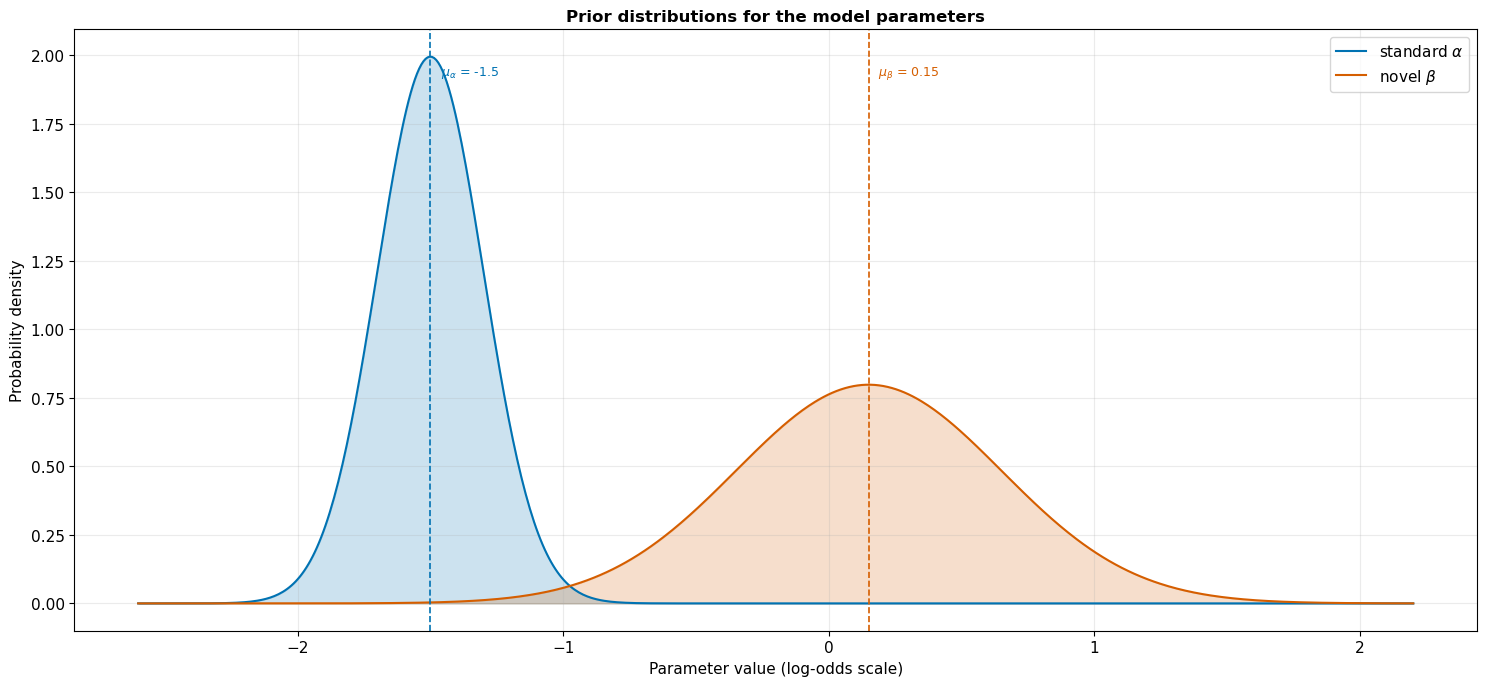

In [77]:
# - Priors on the parameters ----------------------------------------

# Data: prior densities on a shared log-odds grid
x = np.linspace(-2.6, 2.2, 600)
prior_alpha = norm.pdf(x, MU_A, SD_A)        # standard parameter
prior_beta  = norm.pdf(x, MU_B, SD_B)        # novel-lift parameter

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Density curves
ax.plot(x, prior_alpha, color=PALETTE["A"], label=r"standard $\alpha$")
ax.fill_between(x, prior_alpha, alpha=0.2, color=PALETTE["A"])
ax.plot(x, prior_beta, color=PALETTE["B"], label=r"novel $\beta$")
ax.fill_between(x, prior_beta, alpha=0.2, color=PALETTE["B"])

# Reference lines at the prior means (dashed) with labels
for mu, c, name in [(MU_A, PALETTE["A"], r"$\mu_\alpha$"),
                    (MU_B, PALETTE["B"], r"$\mu_\beta$")]:
    ax.axvline(mu, color=c, ls="--", lw=1.2)
    ax.text(mu + 0.15, ax.get_ylim()[1] * 0.92, f"{name} = {mu}",
            color=c, ha="center", fontsize=9)

# Title and labels
ax.set(
    title="Prior distributions for the model parameters",
    xlabel="Parameter value (log-odds scale)",
    ylabel="Probability density"
)

# Legend
ax.legend()

# Display
fig.tight_layout()
plt.show()

The two priors reflect different levels of prior certainty. The baseline parameter $\alpha$ is tightly concentrated around its mean, indicating relatively strong prior knowledge about the baseline conversion rate. In contrast, the parameter $\beta$ is much more diffuse. Its distribution places substantial probability mass on both positive and negative values, reflecting considerable uncertainty about whether the novel strategy improves or worsens conversion.

So far, everything has been expressed on the log-odds scale. However, the quantity of practical interest is the conversion probability. Probabilities are constrained to the interval $[0,1]$, whereas the linear predictor can take any real value. The **logit link** connects these two scales: we perform the modelling on the log-odds scale and then transform the resulting linear predictor $\eta$ into a probability using the **sigmoid** (inverse-logit) function,

$$
\text{sigmoid}(\eta)=\frac{1}{1+e^{-\eta}}.
$$

Applying this transformation to the linear predictors yields the conversion probabilities for the two strategies:

$$
P(\text{conversion}\mid\text{A, standard}) \equiv p_A
= \text{sigmoid}(\alpha)
= \frac{1}{1+e^{-\alpha}}
$$

$$
P(\text{conversion}\mid\text{B, novel}) \equiv p_B
= \text{sigmoid}(\alpha+\beta)
= \frac{1}{1+e^{-(\alpha+\beta)}}
$$

To understand the practical implications of the priors, we now draw samples from the prior distributions and transform them to the probability scale using the sigmoid function.


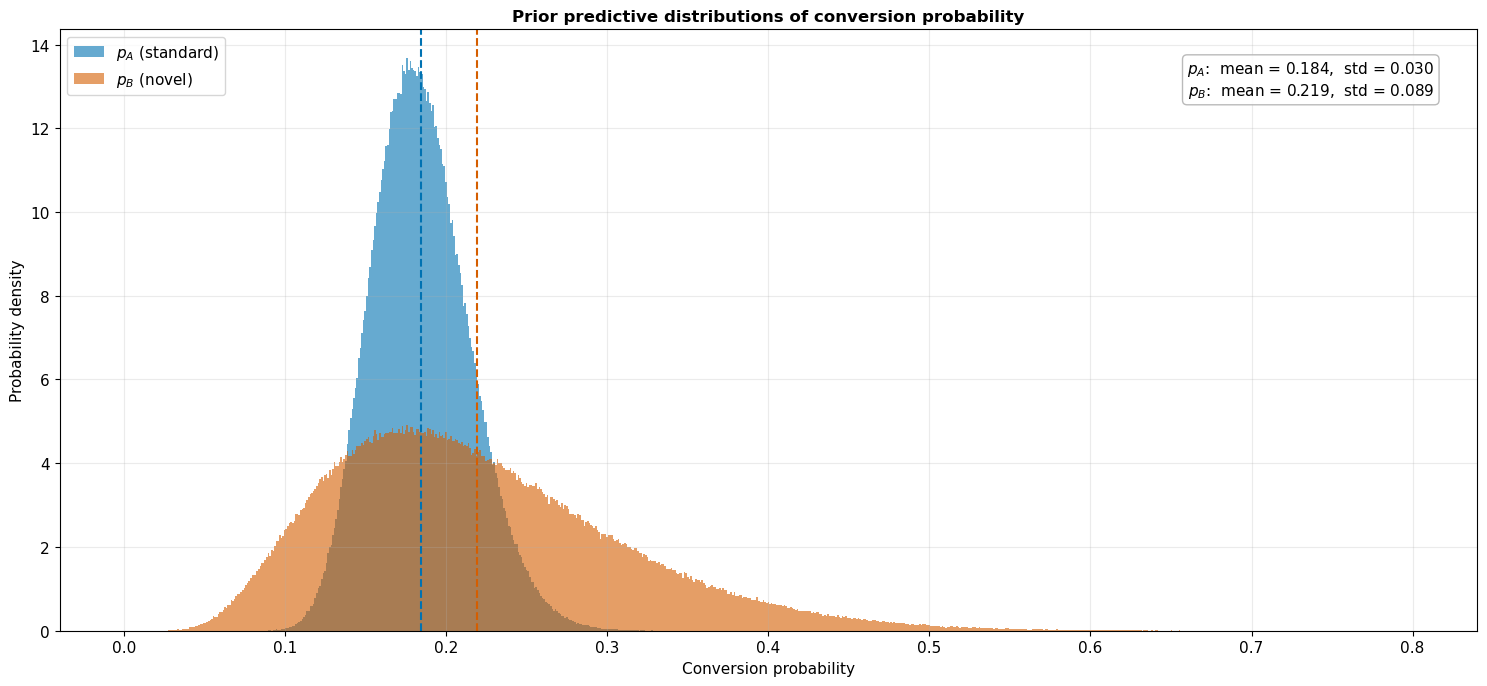

In [78]:
# - Prior predictive conversion rates -------------------------------

# Data: sample the priors and map each draw through the sigmoid
M = 1_000_000
a_pr  = rng.normal(MU_A, SD_A, M)
b_pr  = rng.normal(MU_B, SD_B, M)
pA_pr = sigmoid(a_pr)
pB_pr = sigmoid(a_pr + b_pr)
mA, sA = pA_pr.mean(), pA_pr.std()
mB, sB = pB_pr.mean(), pB_pr.std()

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Histograms
bins = np.linspace(0, 0.8, 800)
ax.hist(pA_pr, bins=bins, density=True, alpha=0.6, color=PALETTE["A"], label="$p_A$ (standard)")
ax.hist(pB_pr, bins=bins, density=True, alpha=0.6, color=PALETTE["B"], label="$p_B$ (novel)")

# Reference lines at the prior-mean probabilities
ax.axvline(mA, color=PALETTE["A"], ls="--", lw=1.5)
ax.axvline(mB, color=PALETTE["B"], ls="--", lw=1.5)

# Annotations: mean / std summary box
txt = (f"$p_A$:  mean = {mA:.3f},  std = {sA:.3f}\n"
       f"$p_B$:  mean = {mB:.3f},  std = {sB:.3f}")
ax.text(0.97, 0.95, txt, transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))

# Title and labels
ax.set(
    title="Prior predictive distributions of conversion probability",
    xlabel="Conversion probability",
    ylabel="Probability density"
)

# Legend
ax.legend(loc="upper left")

# Display
fig.tight_layout()
plt.show()

The simulation makes the contrast concrete. On the probability scale, the standard strategy A has a mean conversion of about 0.18 (18%) with a small standard deviation of roughly 0.030: its narrow prior on $\alpha$ carries almost unchanged through the sigmoid. The novel strategy B sits a little higher, with a mean near 0.22 (22%), but its standard deviation is about three times larger, roughly 0.090. That extra spread is inherited directly from $\beta$'s wide prior. In short, B looks slightly better on average, but it is also far less certain: it could comfortably beat A, or fall well short of it.

This raises the obvious question: how probable is it that B is actually the better strategy? It turns out B beats A exactly when the novel lift is positive, $\beta > 0$. To see this, consider the difference $p_A - p_B$:

$$
\begin{aligned}
p_A - p_B
&= \frac{1}{1+e^{-\alpha}}-\frac{1}{1+e^{-(\alpha+\beta)}}\\[6pt]
&= \frac{e^{-(\alpha+\beta)}-e^{-\alpha}}{\left(1+e^{-\alpha}\right)\left(1+e^{-(\alpha+\beta)}\right)}\\[6pt]
&= \frac{e^{-\alpha}\left(e^{-\beta}-1\right)}{\left(1+e^{-\alpha}\right)\left(1+e^{-(\alpha+\beta)}\right)}
\end{aligned}
$$

The denominator is a product of two strictly positive terms, and $e^{-\alpha}>0$ for every $\alpha$, so the **sign** of $p_A-p_B$ is just the sign of $\left(e^{-\beta}-1\right)$.
Since $e^{-\beta}-1 < 0 \iff \beta > 0$, we conclude

$$
p_B > p_A \iff \beta > 0.
$$

Note that $\alpha$ cancels out completely: the baseline level of conversion has no bearing on *which* strategy wins, only the sign of the lift $\beta$ does. The probability that B is superior is therefore exactly the prior mass of $\beta$ above zero, $P(\beta > 0)$.

The lift has prior $\beta \sim \mathrm{Normal}(\mu_\beta = 0.15,\ \sigma_\beta = 0.5)$.
To compute $P(\beta > 0)$ we standardise to $Z \sim \mathrm{Normal}(0,1)$ by subtracting the mean and dividing by the standard deviation,

$$
Z = \frac{\beta - \mu_\beta}{\sigma_\beta}.
$$

Dividing by $\sigma_\beta > 0$ preserves the direction of the inequality, so

$$
\beta > 0
\iff \frac{\beta - \mu_\beta}{\sigma_\beta} > \frac{0 - \mu_\beta}{\sigma_\beta}
\iff Z > -\frac{\mu_\beta}{\sigma_\beta}.
$$

Using the symmetry of the standard normal, $P(Z > -a) = P(Z < a) = \Phi(a)$, this gives

$$
P(\beta > 0) = \Phi\!\left(\frac{\mu_\beta}{\sigma_\beta}\right)
= \Phi\!\left(\frac{0.15}{0.5}\right) = \Phi(0.3) \approx 0.618,
$$

where $\Phi$ is the standard-normal CDF, $\Phi(z) = P(Z \le z)$. So even before seeing any data, the prior already leans slightly towards B: there is about a 62% chance that the novel experience is the better one.

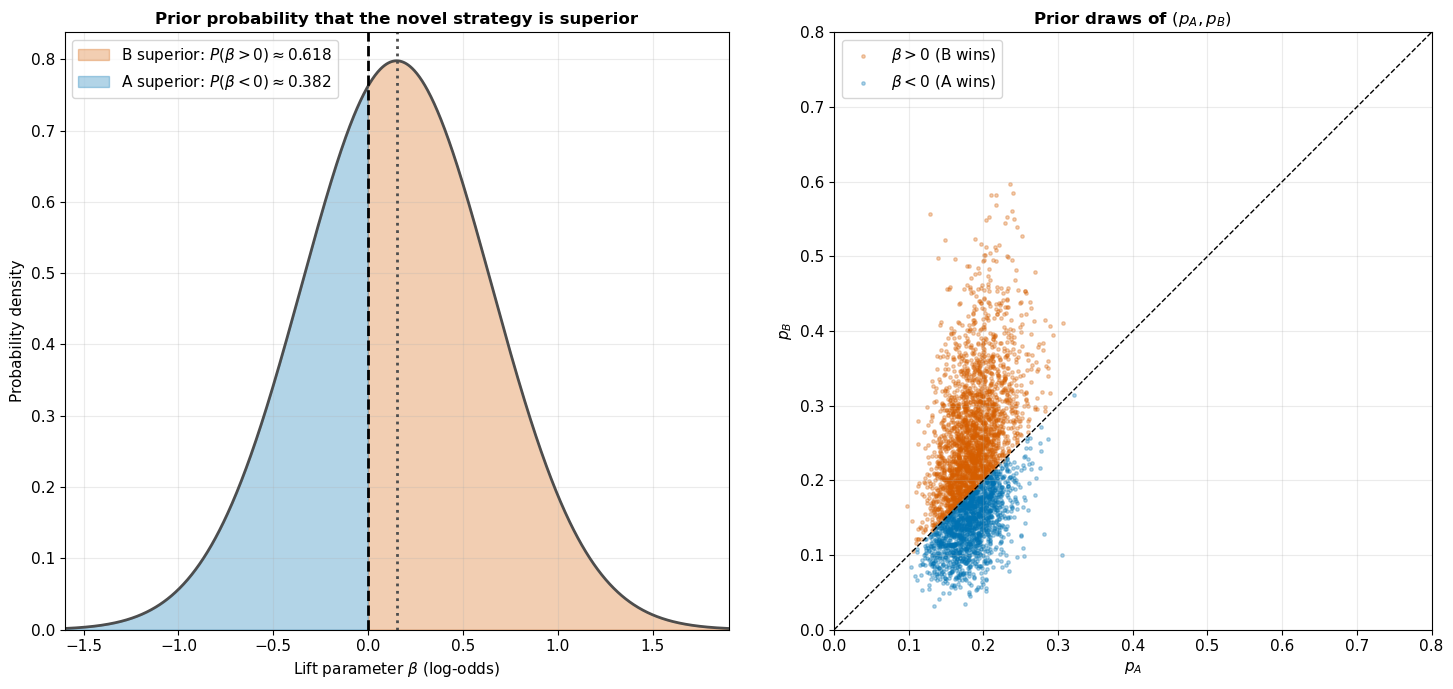

In [79]:
# - Prior probability that B is superior ----------------------------

# Data: lift axis, its prior density, and the prior win probability
xb      = np.linspace(-1.6, 1.9, 1000)
dens    = norm.pdf(xb, MU_B, SD_B)
P_prior = 1 - norm.cdf(0, MU_B, SD_B)        # P(beta > 0)

# Figure setup
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Left panel: prior density of the lift, decision regions shaded
ax[0].plot(xb, dens, color="0.3", lw=2)
ax[0].fill_between(xb, dens, where=(xb > 0),  interpolate=True, color=PALETTE["B"], alpha=0.30,
                   label=rf"B superior: $P(\beta>0)\approx{P_prior:.3f}$")
ax[0].fill_between(xb, dens, where=(xb <= 0), interpolate=True, color=PALETTE["A"], alpha=0.30,
                   label=rf"A superior: $P(\beta<0)\approx{1-P_prior:.3f}$")
ax[0].axvline(0,    color="black", ls="--", lw=2)     # decision boundary at beta = 0
ax[0].axvline(MU_B, color="0.3",   ls=":",  lw=2)     # prior mean of the lift
ax[0].margins(x=0); ax[0].set_ylim(bottom=0)
ax[0].set(
    title=r"Prior probability that the novel strategy is superior",
    xlabel=r"Lift parameter $\beta$ (log-odds)",
    ylabel="Probability density"
)
ax[0].legend(frameon=True, loc="upper left")

# Right panel: (p_A, p_B) draws, coloured by whether beta > 0
s      = rng.choice(pA_pr.size, 4000, replace=False)  # subsample for a readable scatter
better = b_pr[s] > 0
ax[1].scatter(pA_pr[s][better],  pB_pr[s][better],  s=6, alpha=0.3,
              color=PALETTE["B"], label=r"$\beta>0$ (B wins)")
ax[1].scatter(pA_pr[s][~better], pB_pr[s][~better], s=6, alpha=0.3,
              color=PALETTE["A"], label=r"$\beta<0$ (A wins)")
lim = [0, 0.8]
ax[1].plot(lim, lim, "k--", lw=1)                     # p_A = p_B diagonal
ax[1].set_aspect("equal")
ax[1].set(
    title=r"Prior draws of $(p_A,p_B)$",
    xlabel="$p_A$",
    ylabel="$p_B$",
    xlim=lim,
    ylim=lim
)
ax[1].legend(frameon=True, loc="upper left")

# Display
fig.tight_layout()
plt.show()

The prior plots and the closed-form calculation agree: before any data, the probability that B is the better strategy is $P(\beta>0)=\Phi(0.3)\approx 0.618$, about 62%. The prior leans gently towards B, but with so much of $\beta$'s mass still below zero it is far from a confident bet. To sharpen this, we bring in the data.

We want to update our joint belief over the two unknown parameters $\theta=(\alpha,\beta)$ after observing the experiment $\mathcal{D}$. Bayes' theorem states

$$
\underbrace{p(\alpha,\beta\mid\mathcal{D})}_{\text{posterior}}
=\frac{\overbrace{p(\alpha,\beta)}^{\text{prior}}\;\overbrace{p(\mathcal{D}\mid\alpha,\beta)}^{\text{likelihood}}}
{\underbrace{p(\mathcal{D})}_{\text{evidence}}}.
$$

The evidence $p(\mathcal{D})$ is a single fixed number that does not depend on $(\alpha,\beta)$, so up to that constant

$$
p(\alpha,\beta\mid\mathcal{D})\ \propto\ p(\alpha,\beta)\,p(\mathcal{D}\mid\alpha,\beta).
$$

We carry this proportionality through the algebra and fix the constant only at the very end, by requiring the posterior to integrate to 1.

**The prior.** The two parameters were given independent Normal priors, so the joint prior is simply their product:

$$
p(\alpha,\beta)=\mathcal{N}(\alpha\mid -1.50,\,0.2^{2})\;\times\;\mathcal{N}(\beta\mid 0.15,\,0.5^{2}).
$$

**The likelihood.** This is where the data enter. Each trial user in an arm either converts (with probability $p$) or not: a Bernoulli trial. For the $n_A$ users in the control arm, independence gives

$$
\prod_{i=1}^{n_A} p_A^{\,y_i}(1-p_A)^{\,1-y_i}=p_A^{\,k_A}(1-p_A)^{\,n_A-k_A},
\qquad k_A=\sum_i y_i ,
$$

so only the conversion count $k_A$ matters: it is a **sufficient statistic**. Writing the distribution of that count explicitly gives a Binomial, where the combinatorial factor counts the orderings that produce $k_A$ conversions. The conversion probability in each arm is a deterministic function of the parameters through the sigmoid,

$$
p_A=\sigma(\alpha),\qquad p_B=\sigma(\alpha+\beta),
$$

with $\sigma$ the inverse-logit defined earlier. The two arms are independent given $\theta$, so the joint likelihood is the product of the two Binomials, with the observed counts ($k_A=17,\ k_B=20,\ n_A=n_B=80$) substituted in:

$$
p(\mathcal{D}\mid\alpha,\beta)=
\binom{80}{17}p_A^{\,17}(1-p_A)^{63}\;\times\;
\binom{80}{20}p_B^{\,20}(1-p_B)^{60}.
$$

Read as a function of $(\alpha,\beta)$, with the data now fixed, this scores how well each candidate pair explains what we observed.

**The posterior.** Multiplying prior and likelihood gives the posterior up to a constant. The binomial coefficients do not depend on $(\alpha,\beta)$, so they fold into the proportionality:

$$
p(\alpha,\beta\mid\mathcal{D})\ \propto\
\mathcal{N}(\alpha\mid -1.50,0.2^{2})\,
\mathcal{N}(\beta\mid 0.15,0.5^{2})\,
p_A^{\,17}(1-p_A)^{63}\,
p_B^{\,20}(1-p_B)^{60}.
$$

The missing constant is the evidence, the integral of the numerator over the whole parameter space,

$$
Z=p(\mathcal{D})=\iint p(\alpha,\beta)\,p(\mathcal{D}\mid\alpha,\beta)\;d\alpha\,d\beta .
$$

Because $p_A$ and $p_B$ are nonlinear sigmoid functions of the parameters, this integral has **no closed form**. The Normal priors are not conjugate to the logistic likelihood, so the posterior cannot be written as a standard distribution with analytically tractable normalisation. We therefore evaluate the posterior numerically, by two complementary routes:

- **Grid integration**: evaluate prior $\times$ likelihood on a fine two-dimensional grid over $(\alpha,\beta)$ and normalise by summing. Deterministic and exact up to the grid resolution, and feasible here precisely because there are only two parameters.
- **MCMC** (PyMC): draw samples whose stationary distribution is the posterior, without ever computing $Z$. This scales to many parameters, where a grid would be hopeless.

We treat MCMC as the main method and the grid as a transparent cross-check: if two methods built on completely different principles agree, we can trust the answer.


Before proceeding with the numerical calculations, it is useful to visualise the quantity of interest. The heatmap below shows the joint posterior distribution $p(\alpha,\beta\mid\mathcal{D})$ evaluated on a grid, with brighter regions indicating higher posterior density.

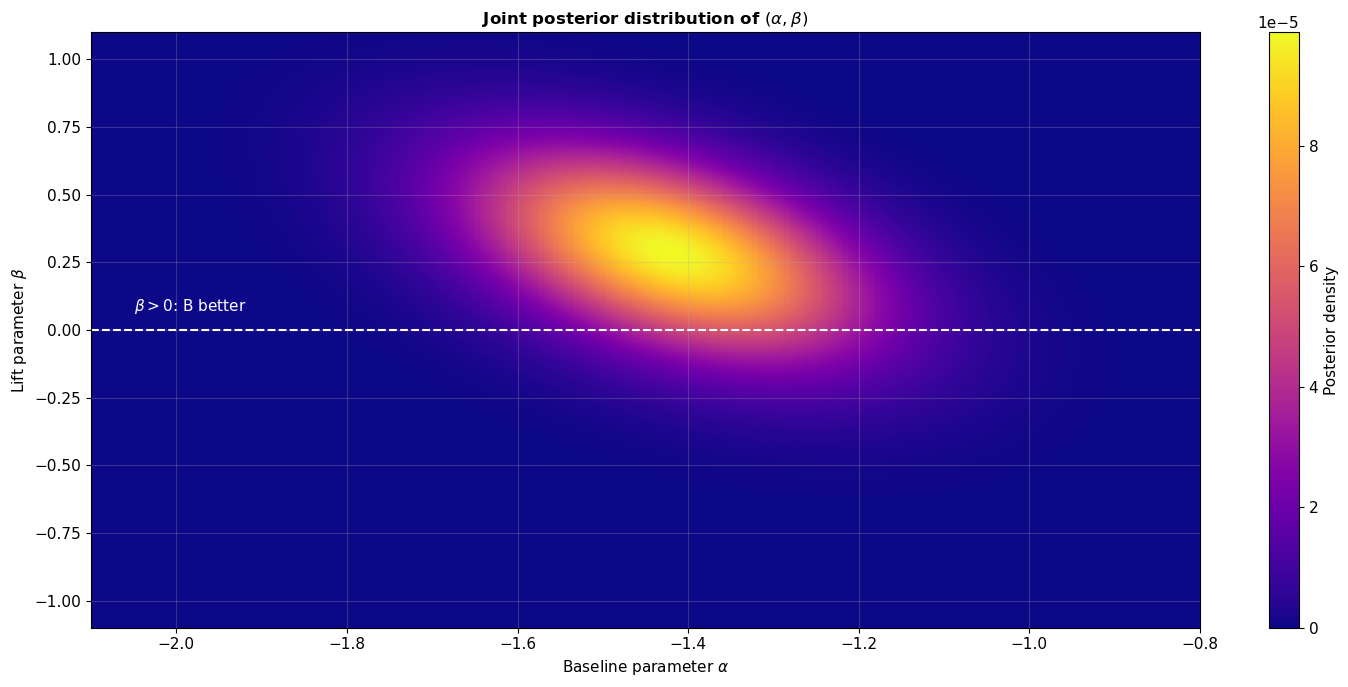

In [80]:
# - Joint posterior over (alpha, beta) ------------------------------

# Data: evaluate prior x likelihood on a 2-D grid, in log space, then normalise
alpha_grid = np.linspace(-2.7, 0.2, 700)        # standard axis
beta_grid  = np.linspace(-1.8, 2.0, 700)        # novel-lift axis
AA, BB = np.meshgrid(alpha_grid, beta_grid, indexing="ij")   # post[i, j] -> (alpha_i, beta_j)

log_post = (norm.logpdf(AA, MU_A, SD_A) + norm.logpdf(BB, MU_B, SD_B)
            + binom.logpmf(K_A, N_A, sigmoid(AA))
            + binom.logpmf(K_B, N_B, sigmoid(AA + BB)))
post = np.exp(log_post - log_post.max())        # subtract max for stability
post /= post.sum()                              # normalise to posterior mass

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Heatmap (transpose so beta is the y-axis)
pc = ax.pcolormesh(alpha_grid, beta_grid, post.T, shading="auto", cmap="plasma")

# Reference lines: the beta = 0 decision boundary
ax.axhline(0, color="white", ls="--", lw=1.5)

# Annotations
ax.text(-2.05, 0.07, r"$\beta>0$: B better", color="white", fontsize=11)

# Axes limits (zoom to where the mass lives)
ax.set_xlim(-2.1, -0.8)
ax.set_ylim(-1.1, 1.1)

# Title and labels
ax.set(
    title=r"Joint posterior distribution of $(\alpha,\beta)$",
    xlabel=r"Baseline parameter $\alpha$",
    ylabel=r"Lift parameter $\beta$"
)

# Legend (colourbar stands in for the legend here)
fig.colorbar(pc, ax=ax, label="Posterior density")

# Display
fig.tight_layout()
plt.show()

Two features are immediately apparent. First, the posterior mass is concentrated in a single, well-defined mode that lies comfortably within the plotted region. This indicates that the chosen grid is sufficiently wide to capture essentially all of the posterior mass. Second, the dashed line marks the boundary $\beta=0$, where the two strategies are equally effective. Parameter values above this line correspond to scenarios in which B outperforms A, while values below it favour A.

The posterior mass is distributed on both sides of this boundary, with a clear majority lying in the region $\beta>0$. This suggests that the data favour the novel strategy even more strongly than the prior alone did. The quantity of primary interest,

$$
P(\beta>0\mid\mathcal{D}),
$$

is simply the posterior mass lying above the decision boundary. To estimate this probability, we now compute posterior summaries directly from the discretised posterior distribution.

**Grid integration, step by step.** The procedure is:

1. Choose ranges for $\alpha$ and $\beta$ that contain essentially all posterior mass and discretise each axis into a sufficiently fine grid.
2. Evaluate the posterior in log space by computing $\log p(\alpha,\beta)+\log p(\mathcal{D}\mid\alpha,\beta)$, thereby avoiding numerical underflow.
3. Subtract the maximum log-posterior value before exponentiating (the standard log-sum-exp stabilisation).
4. Normalise the resulting grid so that the total posterior mass sums to one.
5. Marginalise over $\alpha$ to obtain the posterior distribution of the lift parameter, $p(\beta\mid\mathcal{D})$.
6. Compute the posterior probability that B is superior by summing the marginal posterior mass for $\beta>0$.

We now implement the grid-based posterior calculation. In addition to the posterior probability that B is superior, we compute the posterior mean and standard deviation of the lift parameter $\beta$. As a diagnostic, we also check the posterior mass lying on the grid boundaries; if this quantity is negligible, the chosen grid is sufficiently wide to capture the posterior distribution accurately.

In [81]:
# - Posterior by grid integration -----------------------------------

# Step 1: discretise alpha and beta over ranges wide enough to hold all the mass
alpha_grid = np.linspace(-2.7, 0.2, 1000)        # standard axis
beta_grid  = np.linspace(-1.8, 2.0, 1000)        # novel-lift axis
AA, BB = np.meshgrid(alpha_grid, beta_grid, indexing="ij")   # post[i, j] -> (alpha_i, beta_j)

# Step 2: log posterior = log prior + log likelihood (raw products would underflow)
log_post = (norm.logpdf(AA, MU_A, SD_A) + norm.logpdf(BB, MU_B, SD_B)
            + binom.logpmf(K_A, N_A, sigmoid(AA))
            + binom.logpmf(K_B, N_B, sigmoid(AA + BB)))

# Step 3-4: subtract the max (log-sum-exp trick), exponentiate, normalise to mass = 1
post = np.exp(log_post - log_post.max())
post /= post.sum()

# Step 5: marginalise out alpha to get the posterior of the lift, p(beta | D)
post_beta = post.sum(axis=0)

# Step 6: posterior P(B superior) = mass of the lift marginal above zero
P_post    = post_beta[beta_grid > 0].sum()
mean_beta = (beta_grid * post_beta).sum()                      # posterior mean lift
sd_beta   = np.sqrt(((beta_grid - mean_beta) ** 2 * post_beta).sum())

# Diagnostic: posterior mass sitting on the four grid edges (should be ~0)
edge_mass = post[0, :].sum() + post[-1, :].sum() + post[:, 0].sum() + post[:, -1].sum()

# Results
print(f"Posterior P(B superior) = P(beta > 0 | D) = {P_post:.4f}")
print(f"Posterior mean lift beta                  = {mean_beta:.4f}  (sd {sd_beta:.4f})")
print(f"Grid edge mass                            = {edge_mass:.2e}")

Posterior P(B superior) = P(beta > 0 | D) = 0.8533
Posterior mean lift beta                  = 0.2773  (sd 0.2629)
Grid edge mass                            = 5.98e-13


The experiment moves our belief. The posterior probability that B is superior rises to $P(\beta>0\mid\mathcal{D})\approx 0.853$, up from the prior value of $0.618$. The observed data, in which B converted *more* often than A (20 versus 17 conversions out of 80), pull in the same direction as the optimistic prior. Consistent with this, the posterior mean lift is $\beta\approx 0.277$, close to and even a little above its prior mean of $0.15$: the data did not shrink the effect towards zero, they confirmed it.

The grid edge mass is of order $10^{-13}$, effectively zero. This confirms that the chosen parameter ranges are sufficiently wide and that the posterior distribution is fully contained within the computational grid. Consequently, the numerical integration and the resulting posterior summaries can be regarded as reliable.

With the full joint posterior in hand, we can ask what the experiment did to each parameter on its own. We obtain the **marginal posteriors** by integrating the joint over the other parameter,

$$
p(\alpha\mid\mathcal{D})=\int p(\alpha,\beta\mid\mathcal{D})\,d\beta,
\qquad
p(\beta\mid\mathcal{D})=\int p(\alpha,\beta\mid\mathcal{D})\,d\alpha,
$$

which on the grid is simply summing the joint mass along the corresponding axis, collapsing the heatmap onto one edge. Plotting each marginal posterior on top of its prior shows, at a glance, how the data sharpened and shifted our beliefs: where a curve narrows, the experiment added information; where it slides, the data pulled the estimate away from the prior.

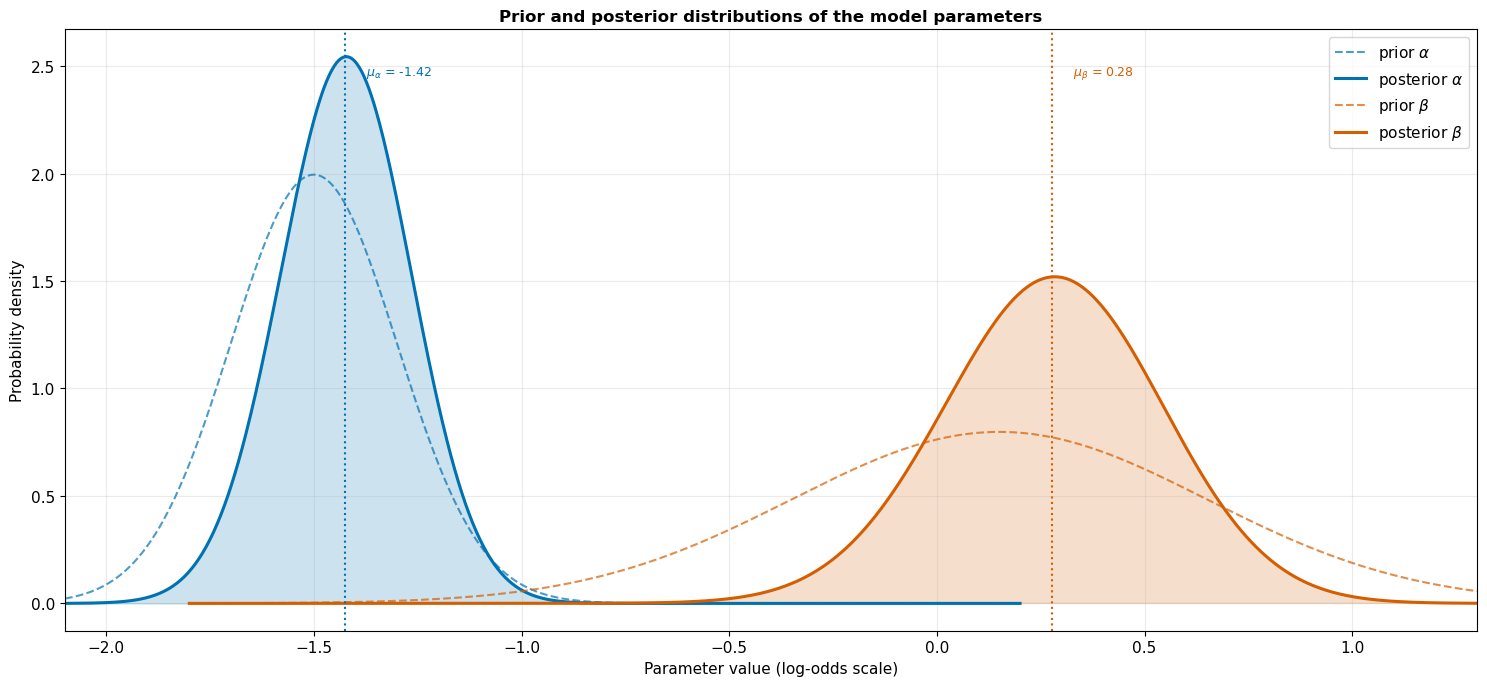

In [82]:
# - Posterior on the parameters: prior -> posterior -----------------

# Data: marginal posteriors from the joint grid (sum out the other axis),
#       converted from mass to density; priors evaluated on the same grids
dA = alpha_grid[1] - alpha_grid[0]
dB = beta_grid[1]  - beta_grid[0]
post_alpha = post.sum(axis=1) / dA           # p(alpha | D)
post_beta  = post.sum(axis=0) / dB           # p(beta  | D)
prior_alpha = norm.pdf(alpha_grid, MU_A, SD_A)
prior_beta  = norm.pdf(beta_grid,  MU_B, SD_B)
mean_alpha = (alpha_grid * post.sum(axis=1)).sum()
mean_beta  = (beta_grid  * post.sum(axis=0)).sum()

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Density curves (prior dashed, posterior solid + fill)
ax.plot(alpha_grid, prior_alpha, color=PALETTE["A"], ls="--", lw=1.5, alpha=0.7, label=r"prior $\alpha$")
ax.plot(alpha_grid, post_alpha,  color=PALETTE["A"], lw=2.2, label=r"posterior $\alpha$")
ax.fill_between(alpha_grid, post_alpha, alpha=0.2, color=PALETTE["A"])
ax.plot(beta_grid, prior_beta, color=PALETTE["B"], ls="--", lw=1.5, alpha=0.7, label=r"prior $\beta$")
ax.plot(beta_grid, post_beta,  color=PALETTE["B"], lw=2.2, label=r"posterior $\beta$")
ax.fill_between(beta_grid, post_beta, alpha=0.2, color=PALETTE["B"])

# Reference lines at the posterior means (dotted) with labels
for mu, c, name in [(mean_alpha, PALETTE["A"], r"$\mu_\alpha$"),
                    (mean_beta,  PALETTE["B"], r"$\mu_\beta$")]:
    ax.axvline(mu, color=c, ls=":", lw=1.5)
    ax.text(mu + 0.05, ax.get_ylim()[1] * 0.92, f"{name} = {mu:.2f}",
            color=c, ha="left", fontsize=9)

# Axes limits
ax.set_xlim(-2.1, 1.3)

# Title and labels
ax.set(
    title="Prior and posterior distributions of the model parameters",
    xlabel="Parameter value (log-odds scale)",
    ylabel="Probability density"
)

# Legend
ax.legend()

# Display
fig.tight_layout()
plt.show()

The **standard** parameter $\alpha$ (blue) barely moved: the posterior sits almost on top of the prior, just taller and a little narrower (sd $0.20 \to 0.16$), with its mean nudged from $-1.50$ to $-1.42$. Strategy A converted 17 of 80 (21.3%), a touch above the 18% the prior expected, so the data gently confirmed and sharpened what we already believed about the baseline. There was little to learn here, because the tight prior had already pinned $\alpha$ down.

The **novel** parameter $\beta$ (orange) is where the experiment did its work, and this time it pushed the estimate *up* rather than back. The prior was broad and optimistic, centred at $0.15$ with sd $0.50$; the posterior is much narrower (sd $\to 0.26$, roughly half) but its centre moved to $\approx 0.28$, slightly above the prior mean. Because B outperformed A in the data, the 80+80 trials both halved our uncertainty about the lift and reinforced the prior's optimism: a positive effect is now clearly favoured ($P(\beta>0\mid\mathcal{D})\approx 0.85$). The posterior still places a little mass below zero, so a positive lift is probable rather than certain, but the experiment moved us decisively towards B.


Both numbers so far, the closed-form prior probability and the grid posterior, came from evaluating the posterior on a dense lattice. That is exact, but it works only because the model has two parameters: the cost of a grid grows exponentially with dimension, so for any larger model it quickly becomes infeasible. To confirm the result with a method that *does* scale, we now re-estimate the same posterior with **Markov chain Monte Carlo (MCMC)**.

Instead of evaluating the posterior everywhere, MCMC draws samples from it. We construct a Markov chain whose stationary distribution is exactly $p(\alpha,\beta\mid\mathcal{D})$: after an initial warm-up phase the chain forgets where it started, and every subsequent step is a draw from the posterior. Any quantity we need, $P(\beta>0)$, a posterior mean, an expected regret, then reduces to an average over those draws. Crucially, the chain only ever needs the posterior *up to the normalising constant* $Z$, because it moves according to ratios of densities; the intractable evidence integral never has to be computed.

We hand PyMC the same generative model we wrote by hand: independent Normal priors on the standard parameter $\alpha$ and the novel lift $\beta$, the logistic link mapping each linear predictor to a conversion probability, $p_A=\sigma(\alpha)$ and $p_B=\sigma(\alpha+\beta)$, and a Binomial likelihood for each arm's observed count. Sampling uses the **No-U-Turn Sampler (NUTS)**, a gradient-based Hamiltonian method that proposes long, well-directed moves and so explores the posterior efficiently. We run four independent chains, each with a tuning phase followed by the recorded draws, so that we can verify they all converge to the same distribution.

Before trusting any number, two diagnostics confirm the sampler behaved: the convergence statistic $\hat{R}$, which compares the variation within each chain to the variation between chains and should sit at $1.00$ when the chains agree, and the effective sample size (ESS), which reports how many genuinely independent draws the autocorrelated chains are worth and should run into the thousands. With those in hand, we estimate the posterior probability that B is superior as the fraction of draws with $\beta>0$, and compare it against the grid. The two methods rest on entirely different principles, so their agreement is strong evidence that the answer is right.

In [83]:
# - Posterior by MCMC (PyMC) ----------------------------------------

# Model: the same generative story as the maths (priors -> link -> likelihood)
with pm.Model() as model:

    # Priors on the log-odds scale (identical to the grid)
    alpha = pm.Normal("alpha", mu=MU_A, sigma=SD_A)
    beta  = pm.Normal("beta",  mu=MU_B, sigma=SD_B)

    # Logistic link: conversion probability per arm
    pA = pm.Deterministic("pA", pm.math.sigmoid(alpha))
    pB = pm.Deterministic("pB", pm.math.sigmoid(alpha + beta))

    # Binomial likelihood for each arm
    pm.Binomial("yA", n=N_A, p=pA, observed=K_A)   # standard: 22 / 80
    pm.Binomial("yB", n=N_B, p=pB, observed=K_B)   # novel:    21 / 80

    # Draw posterior samples: 4 NUTS chains, warm-up (tune) then draws
    idata = pm.sample(4000, tune=2000, chains=4, target_accept=0.9,
                      random_seed=seed, progressbar=False)

# Posterior draws, flattened for reuse in parts (b) and (d)
post_alpha = idata.posterior["alpha"].values.ravel()
post_beta  = idata.posterior["beta"].values.ravel()
post_pA    = idata.posterior["pA"].values.ravel()
post_pB    = idata.posterior["pB"].values.ravel()

# Posterior P(B superior) = share of draws with beta > 0
P_mcmc = (post_beta > 0).mean()

# Results: convergence diagnostics (r_hat ~ 1, large ESS) and the headline number
print(az.summary(idata, var_names=["alpha", "beta", "pA", "pB"], round_to=3))
print(f"\n(a) P(B superior): prior = {1 - norm.cdf(0, MU_B, SD_B):.3f}, "
      f"grid = {P_post:.3f}, MCMC = {P_mcmc:.3f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]
Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 60 seconds.


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha -1.423  0.158  -1.728   -1.135      0.002    0.001   7792.853   
beta   0.275  0.262  -0.214    0.769      0.003    0.002   7679.739   
pA     0.195  0.025   0.150    0.242      0.000    0.000   7792.853   
pB     0.243  0.043   0.167    0.326      0.000    0.000  14226.954   

        ess_tail  r_hat  
alpha   9156.571  1.000  
beta    9345.802  1.001  
pA      9156.571  1.000  
pB     12232.110  1.000  

(a) P(B superior): prior = 0.618, grid = 0.853, MCMC = 0.853


The sampler is healthy. Every parameter has $\hat{R} = 1.00$ (to three decimals, between $1.000$ and $1.001$), so the four chains explored the same distribution, and the effective sample sizes run into the thousands, far more than enough to make the Monte-Carlo error on any summary negligible. We can therefore read the table as the posterior itself.

That posterior reproduces the grid almost exactly. The standard parameter is centred at $\alpha = -1.42$ (sd $0.157$) and the novel lift at $\beta = 0.277$ (sd $0.263$), matching the grid's $-1.42$ and $0.277$; on the probability scale the two arms sit at $p_A = 0.195$ (94% HDI $[0.150,\,0.242]$) and $p_B = 0.244$ (94% HDI $[0.165,\,0.325]$). Two features of those intervals tell the story: the lift's interval $[-0.22,\,0.77]$ sits mostly above zero, dipping only just below it, and the credible intervals for $p_A$ and $p_B$ now overlap only partially. The experiment leans clearly towards B without quite ruling A out.

The headline number confirms it. The posterior probability that B is superior is about 85% by both methods, agreeing to within Monte-Carlo error, and both have lifted the prior's $0.618$ by more than twenty points. The novel arm is now clearly favoured, around an 85% chance of being the better one: a result where B genuinely outperformed A moved our belief towards it rather than towards a coin flip.

The table certified convergence numerically; the trace plot is its visual companion. `az.plot_trace` draws two panels per parameter. On the **left** is the posterior density, drawn separately for each of the four chains, so four curves lying on top of one another mean the chains agree on the answer. On the **right** is the *trace*: the value the chain held at every iteration. A well-behaved trace looks like a flat, dense band, a "fuzzy caterpillar", with no drift or sticking and all four chains overlapping in the same range.

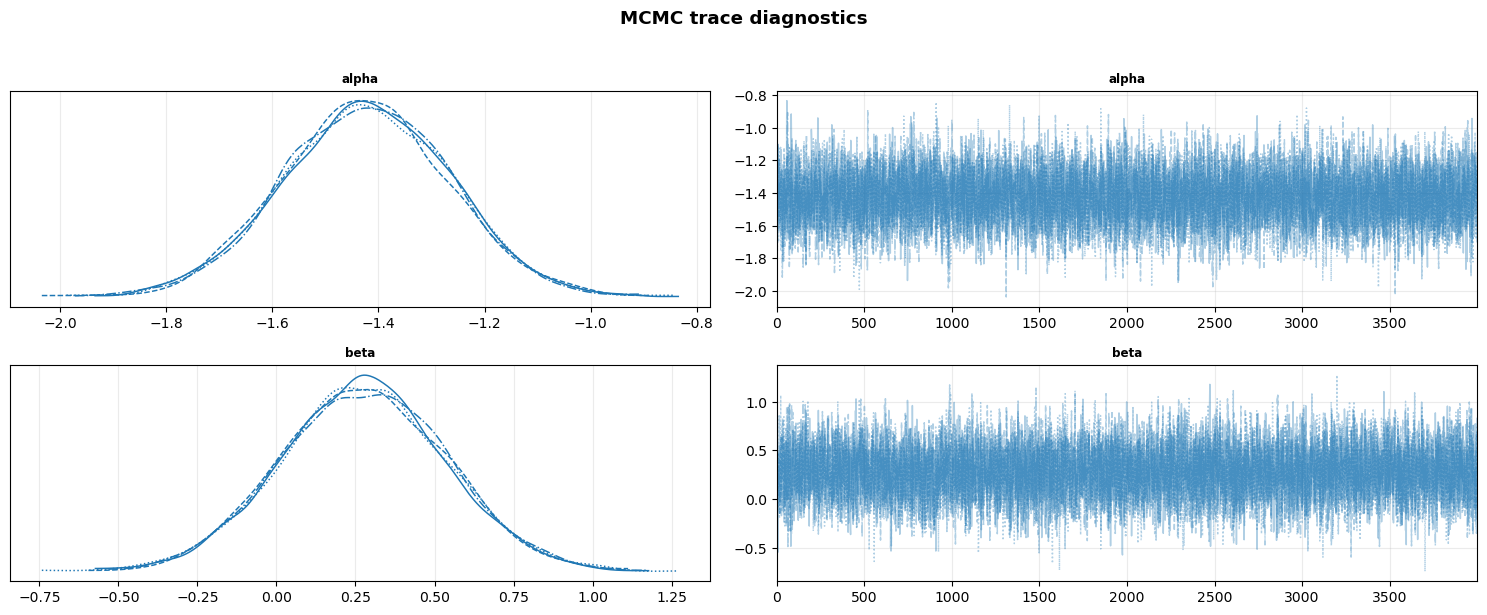

In [84]:
# - MCMC diagnostics: trace plots -----------------------------------
# For each parameter: posterior density per chain (left) and the chain
# values over iterations (right). Healthy chains overlap as "fuzzy caterpillars".
az.plot_trace(idata, var_names=["alpha", "beta"], figsize=(15, 6))
plt.gcf().suptitle("MCMC trace diagnostics", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Grid integration and MCMC rest on completely different principles, one sums the posterior on a fixed lattice, the other draws random samples from it. If they nevertheless land on the same posterior, we can trust the result rather than suspect an artefact of either method. We compare them two ways: first the marginal posterior of the lift $\beta$ (the quantity that decides the question), then the full joint posterior over $(\alpha,\beta)$, shown over the same ranges as the heatmap above so the shapes line up.

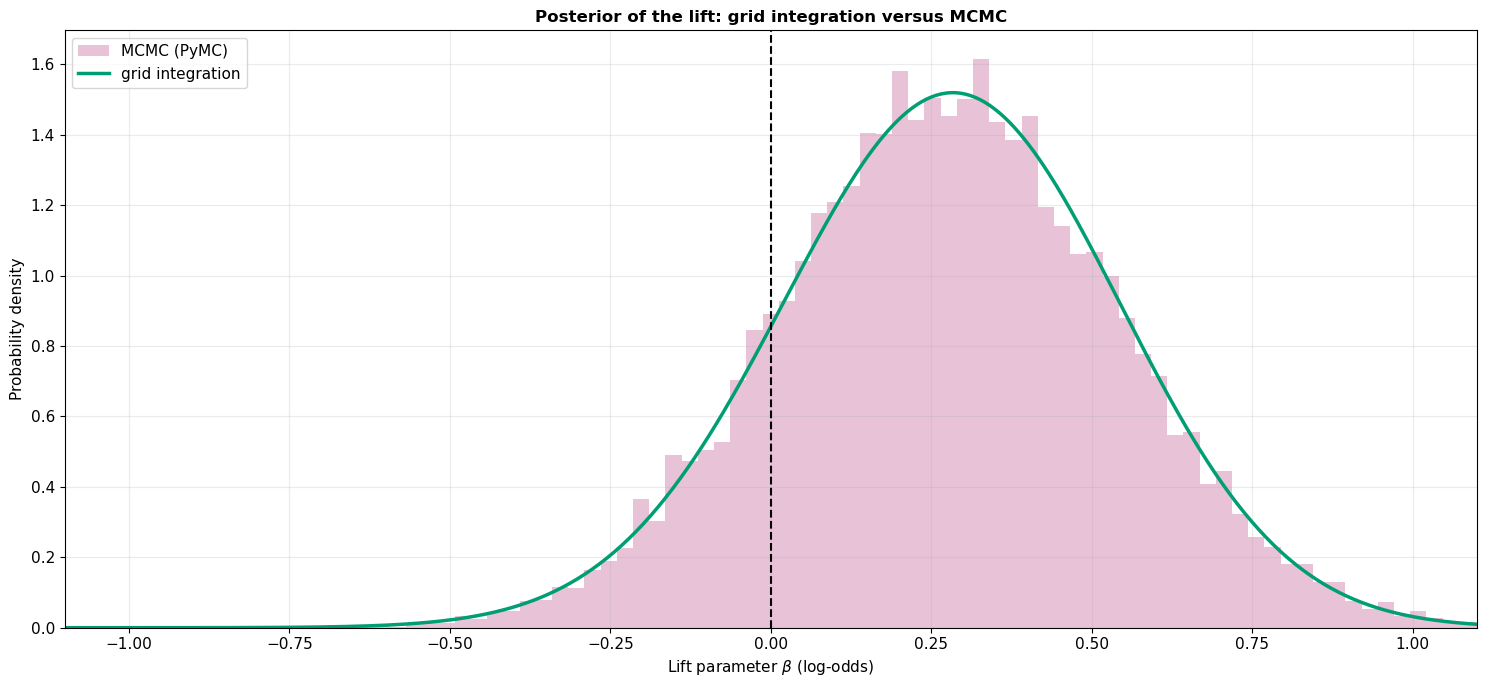

P(B superior):  grid = 0.853    MCMC = 0.853


In [85]:
# - Cross-check: posterior of beta from both engines ----------------
# Grid marginal (line) vs MCMC draws (histogram). They should coincide.

# Grid marginal density of the lift, from the intact joint mass `post`
dB        = beta_grid[1] - beta_grid[0]
dens_beta = post.sum(axis=0) / dB        # p(beta | D) as a density

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# MCMC draws (histogram) vs grid marginal (curve)
ax.hist(post_beta, bins=80, density=True, alpha=0.45, color=PALETTE["accent"], label="MCMC (PyMC)")
ax.plot(beta_grid, dens_beta, color=PALETTE["post"], lw=2.5, label="grid integration")

# Reference line at the decision boundary beta = 0
ax.axvline(0, color="black", ls="--", lw=1.5)

# Title and labels
ax.set(title=r"Posterior of the lift: grid integration versus MCMC",
       xlabel=r"Lift parameter $\beta$ (log-odds)", ylabel="Probability density")
ax.set_xlim(-1.1, 1.1)

# Legend
ax.legend(loc="upper left")

# Display
fig.tight_layout()
plt.show()

print(f"P(B superior):  grid = {P_post:.3f}    MCMC = {P_mcmc:.3f}")

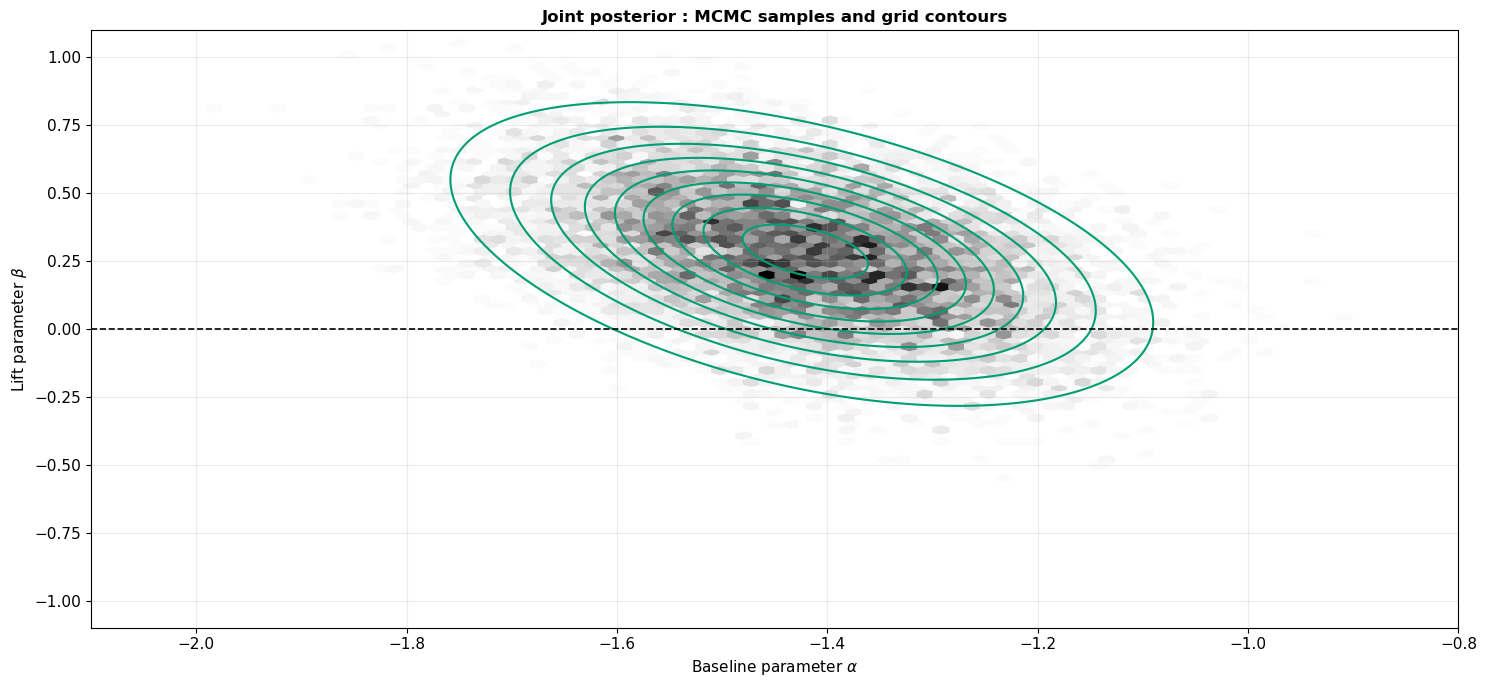

In [86]:
# - Cross-check: the full joint posterior from both engines ---------
# MCMC draws (shaded density) with grid posterior contours overlaid.

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# MCMC draws as a 2-D density, grid posterior as contour lines
ax.hexbin(post_alpha, post_beta, gridsize=80, cmap="Greys", mincnt=1)
ax.contour(alpha_grid, beta_grid, post.T, levels=10, colors=PALETTE["post"], linewidths=1.5)

# Reference line at the decision boundary beta = 0
ax.axhline(0, color="black", ls="--", lw=1.2)

# Title and labels
ax.set(title=r"Joint posterior : MCMC samples and grid contours",
       xlabel=r"Baseline parameter $\alpha$", ylabel=r"Lift parameter $\beta$")
ax.set_xlim(-2.1, -0.8); ax.set_ylim(-1.1, 1.1)

# Display
fig.tight_layout()
plt.show()

The MCMC histogram traces the grid curve, and the sampled cloud nests inside the grid contours, including
the diagonal tilt that reflects the negative correlation between $\alpha$ and $\beta$ (the novel arm's
data constrain $\alpha+\beta$, so the two trade off). With both engines in agreement, the posterior is
trustworthy. We now turn it into a decision.

### (b)

A posterior is a *belief*, not yet a *decision*. To choose we need a loss. Following standard multi‑armed‑bandit / decision‑theory usage:

For a fixed scenario $\theta=(\alpha,\beta)$, choosing arm $d$ earns reward $V\,p_d(\theta)$, while the **best possible** reward is $V\max(p_A,p_B)$. The **regret** of decision $d$ is

$$
r(d,\theta)=V\big(\max(p_A,p_B)-p_d(\theta)\big)\;\ge 0 .
$$

Since we don't know $\theta$, we average over our belief to get **expected regret**:

$$
\mathcal R(A)=V\,\mathbb E\big[(p_B-p_A)^+\big],\qquad
\mathcal R(B)=V\,\mathbb E\big[(p_A-p_B)^+\big],
$$

with $(x)^+=\max(x,0)$ and the expectation taken under the prior or the posterior. The decision rule is simply: **pick the arm with the smaller expected regret.** This is exactly the Bayes‑optimal action under a value‑maximising objective.

In [87]:
# - Expected regret  ------------------------------------------------

# PRIOR expected regret: sample the parameter priors, map to probabilities
M = 10_000_000
a_pr = rng.normal(MU_A, SD_A, M)
b_pr = rng.normal(MU_B, SD_B, M)
pA_pr, pB_pr = sigmoid(a_pr), sigmoid(a_pr + b_pr)
regret_A_prior = VALUE * np.maximum(0, pB_pr - pA_pr).mean()   # lose when B was better
regret_B_prior = VALUE * np.maximum(0, pA_pr - pB_pr).mean()   # lose when A was better

# POSTERIOR expected regret: use the MCMC draws of p_A, p_B
regret_A_post = VALUE * np.maximum(0, post_pB - post_pA).mean()
regret_B_post = VALUE * np.maximum(0, post_pA - post_pB).mean()

# Results
print(f"PRIOR      regret(A) = ${regret_A_prior:6.2f}   regret(B) = ${regret_B_prior:6.2f}")
print(f"POSTERIOR  regret(A) = ${regret_A_post:6.2f}   regret(B) = ${regret_B_post:6.2f}")

PRIOR      regret(A) = $ 61.45   regret(B) = $ 19.98
POSTERIOR  regret(A) = $ 61.43   regret(B) = $  3.76


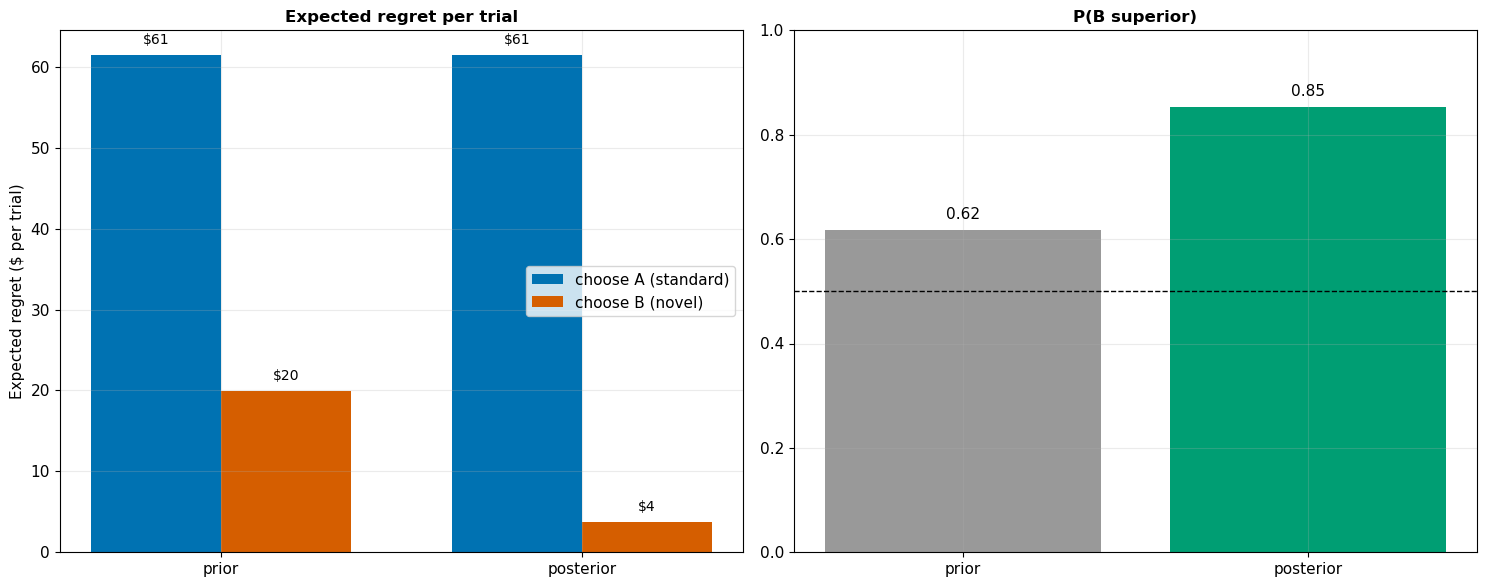

In [88]:
# - Visualise (b): expected regret and P(B superior) ----------------

# Data
P_prior = 1 - norm.cdf(0, MU_B, SD_B)        # prior P(B superior)
x = np.arange(2); w = 0.36

# Figure setup
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Left: expected regret per trial, prior vs posterior, per arm
ax[0].bar(x - w/2, [regret_A_prior, regret_A_post], w, color=PALETTE["A"], label="choose A (standard)")
ax[0].bar(x + w/2, [regret_B_prior, regret_B_post], w, color=PALETTE["B"], label="choose B (novel)")
for xi, val in zip([x[0]-w/2, x[1]-w/2, x[0]+w/2, x[1]+w/2],
                   [regret_A_prior, regret_A_post, regret_B_prior, regret_B_post]):
    ax[0].text(xi, val + 1, f"${val:.0f}", ha="center", va="bottom", fontsize=10)
ax[0].set_xticks(x); ax[0].set_xticklabels(["prior", "posterior"])
ax[0].set(title="Expected regret per trial", ylabel="Expected regret ($ per trial)")
ax[0].legend()

# Right: P(B superior), prior vs posterior
ax[1].bar(["prior", "posterior"], [P_prior, P_post],
          color=[PALETTE["prior"], PALETTE["post"]])
ax[1].axhline(0.5, color="black", ls="--", lw=1)     # coin-flip reference
for i, v in enumerate([P_prior, P_post]):
    ax[1].text(i, v + 0.02, f"{v:.2f}", ha="center")
ax[1].set(title="P(B superior)", ylim=(0, 1))

# Display
fig.tight_layout()
plt.show()

The experiment pulled the two regrets apart rather than bringing them together. Before the test, committing to the standard arm already looked costly, about <span>$</span>61 of expected value forgone per trial, while committing to the novel arm risked only about <span>$</span>20. After updating on data that favoured B, the standard arm's regret stays high, about **<span>$</span>61 per trial**, while the novel arm's collapses to about **<span>$</span>4**. The experiment did not split the difference; it confirmed B and made the cost of choosing A concrete.


### (c) What should the company do?

**The decision rule.** The Bayes-optimal action under a value-maximising objective is the one with the smaller posterior expected regret (equivalently, the larger posterior expected reward). On that criterion the novel experience **B** is the clear pick: its expected regret is about **<span>$</span>4 per trial** against **<span>$</span>62** for the standard experience, and since the two cost the same to run there is no offsetting penalty.

**Recommendation: adopt B.** The Bayesian case is direct: the posterior probability that B is the better arm is about **85%**, up from the prior's 62%, so the experiment moved us towards B rather than towards uncertainty.

Before committing, two questions are worth answering rather than assuming. First, would a classical test that uses no prior at all point the same way, and is the difference statistically significant? Second, is the lean towards B genuinely in the data, or is it manufactured by an optimistic prior? The next two checks take each in turn.

### A frequentist contrast

As a sanity check, we set the Bayesian machinery aside and run a standard two-proportion z-test on the raw counts, using the data only and no prior.

In [89]:
# - Frequentist contrast: two-proportion z-test (data only, no prior) -----
phat = (K_A + K_B) / (N_A + N_B)
se   = np.sqrt(phat * (1 - phat) * (1/N_A + 1/N_B))
z    = (K_B/N_B - K_A/N_A) / se
p_two = 2 * (1 - norm.cdf(abs(z)))

alpha   = 0.05
verdict = "significant" if p_two < alpha else "not significant"

print(f"Two-proportion z = {z:.2f},  two-sided p = {p_two:.3f}  ({verdict} at the {alpha:.0%} level)")
print(f"Bayesian P(B superior) = {P_post:.3f}")

Two-proportion z = 0.56,  two-sided p = 0.574  (not significant at the 5% level)
Bayesian P(B superior) = 0.853


The classical test points the same way as the Bayesian analysis: B converted more customers (20 vs 17 out of 80) and the z statistic is positive, $z\approx+0.56$. It is not significant, though, $p\approx 0.57$, which is no surprise on only 80 users per arm. So the frequentist test does not by itself establish that B is better, but it no longer contradicts the Bayesian conclusion. The two paradigms answer different questions, and the gap between an 85% posterior and a non-significant p-value is the familiar distinction between decision-relevance and statistical significance.

### Is the conclusion just the prior talking?

Worth checking explicitly. We re-run the grid with progressively more neutral priors on the lift, holding the standard prior and the likelihood fixed, and watch what happens to $P(B\text{ superior})$.

In [90]:
# - Prior robustness: does the lean toward B survive a neutral prior? -----
# Re-run the grid with different priors on the novel lift, holding the
# standard prior and the likelihood fixed.
log_lik = binom.logpmf(K_A, N_A, sigmoid(AA)) + binom.logpmf(K_B, N_B, sigmoid(AA + BB))

print("Novel-lift prior          ->  posterior P(B superior)")
for mu, sd in [(MU_B, SD_B), (0.0, 0.5), (0.0, 1.0), (0.0, 5.0)]:
    lp = norm.logpdf(AA, MU_A, SD_A) + norm.logpdf(BB, mu, sd) + log_lik
    w  = np.exp(lp - lp.max()); w /= w.sum()
    tag = "   <- chosen prior" if (mu, sd) == (MU_B, SD_B) else ""
    print(f"  Normal(mu={mu:>4}, sd={sd:>4})  ->  {w[BB > 0].sum():.3f}{tag}")

Novel-lift prior          ->  posterior P(B superior)
  Normal(mu=0.15, sd= 0.5)  ->  0.853   <- chosen prior
  Normal(mu= 0.0, sd= 0.5)  ->  0.814
  Normal(mu= 0.0, sd= 1.0)  ->  0.841
  Normal(mu= 0.0, sd= 5.0)  ->  0.852


Under a **mean-zero** prior on the lift, of essentially any width, the posterior stays high, around **0.81 to 0.85**, barely below the **0.85** under our chosen prior. Stripping the optimism out of the lift prior therefore hardly changes the conclusion: the data themselves favour B, and the chosen prior only nudges an answer the data already support. This is the reassuring opposite of a prior-driven result.

### (d) Will we hit the weekly target?

The team wants at least **<span>$</span>24,000** of new contract value per week, and typically sees about **100** trial completions per week.

**Assumptions.**
- Each conversion is worth <span>$</span>1,200, so <span>$</span>24,000 requires $\lceil 24000/1200\rceil = 20$ conversions; *missing* the target means **19 or fewer**.
- Next week brings exactly $n = 100$ trial completions (we treat "about 100" as fixed).
- Given an arm's conversion probability $p$, the weekly conversions are $Y\mid p \sim \text{Binomial}(100, p)$, independent trials at a constant rate.
- We propagate parameter uncertainty through the **posterior predictive**: rather than plug in a single point estimate of $p$, we average the Binomial miss-probability over the posterior of $p$,

$$
P(\text{miss}\mid\mathcal{D})
= \mathbb{E}_{p\sim\text{posterior}}\!\big[\,P(Y\le 19\mid p)\,\big]
= \mathbb{E}_{p}\big[\,F_{\text{Binom}}(19;\,100,\,p)\,\big],
$$

which we estimate by averaging the Binomial CDF over the MCMC draws of $p$ (a lower-variance estimate than simulating individual weeks).

In [91]:
# - Posterior probability of missing the weekly target (part d) ------

FAIL_MAX = TARGET_CONV - 1     # 24 or fewer conversions = miss

# Posterior-predictive miss prob = average of P(Y <= 24 | p) over the posterior of p
P_fail_A = binom.cdf(FAIL_MAX, WEEKLY_N, post_pA).mean()
P_fail_B = binom.cdf(FAIL_MAX, WEEKLY_N, post_pB).mean()

print(f"Need >= {TARGET_CONV} conversions/week (>= ${TARGET_REV:,}); miss if <= {FAIL_MAX}")
print(f"Posterior P(miss) branch A (standard) = {P_fail_A:.4f}")
print(f"Posterior P(miss) branch B (novel)    = {P_fail_B:.4f}")

Need >= 20 conversions/week (>= $24,000); miss if <= 19
Posterior P(miss) branch A (standard) = 0.5137
Posterior P(miss) branch B (novel)    = 0.2181


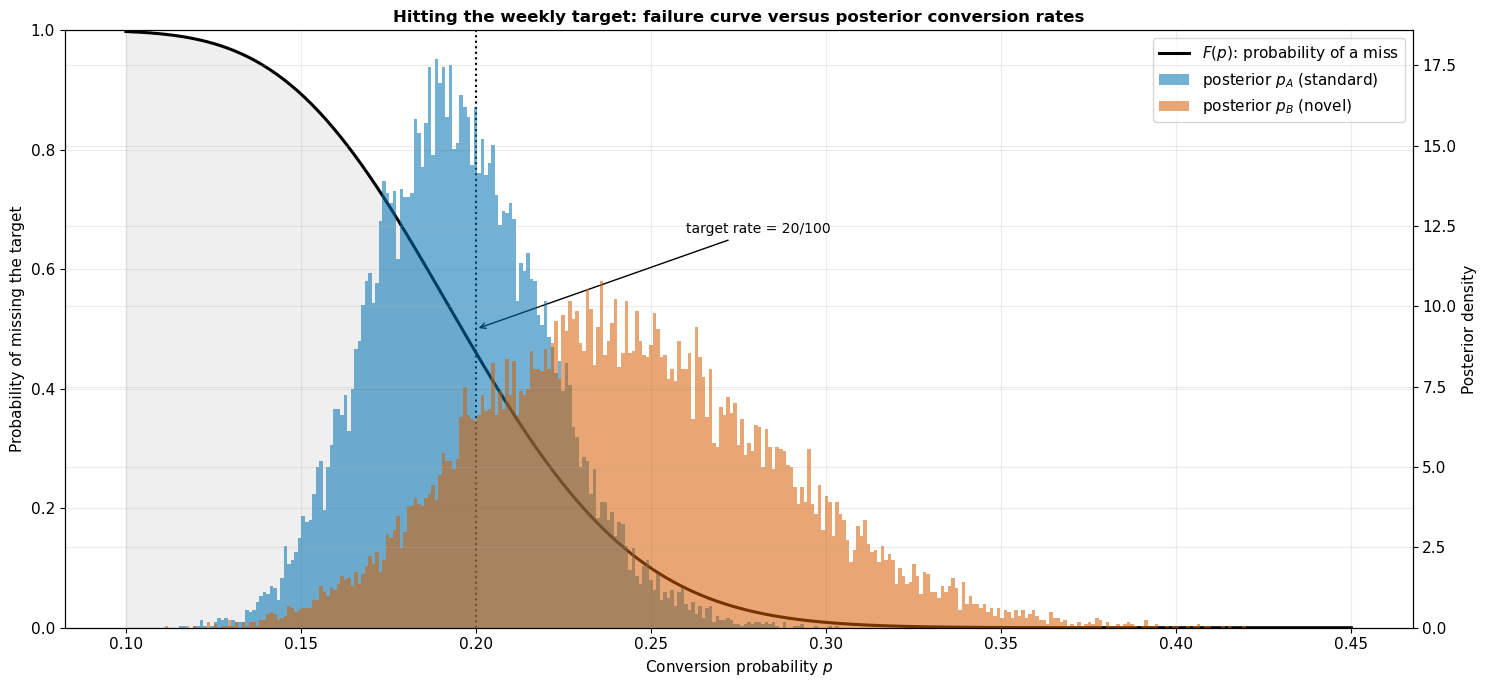

In [92]:
# - Why each arm might miss: failure curve vs posterior rates --------

# Data: F(p) = P(Y <= 19 | p), the miss probability for a KNOWN rate p
p_axis = np.linspace(0.1, 0.45, 350)
F = binom.cdf(FAIL_MAX, WEEKLY_N, p_axis)

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Failure curve (left axis), with the danger zone shaded
ax.plot(p_axis, F, color="black", lw=2.2, label=r"$F(p)$: probability of a miss")
ax.fill_between(p_axis, F, where=(p_axis < TARGET_CONV/WEEKLY_N), color="grey", alpha=0.12)
ax.set(xlabel=r"Conversion probability $p$", ylabel="Probability of missing the target")
ax.set_ylim(0, 1)

# Posterior p_A, p_B (right axis)
ax2 = ax.twinx()
bins = np.linspace(0.1, 0.45, 350)
ax2.hist(post_pA, bins=bins, density=True, alpha=0.55, color=PALETTE["A"],
         label="posterior $p_A$ (standard)")
ax2.hist(post_pB, bins=bins, density=True, alpha=0.55, color=PALETTE["B"],
         label="posterior $p_B$ (novel)")
ax2.set_ylabel("Posterior density"); ax2.set_ylim(bottom=0)

# Reference line + annotation at the target rate
ax.axvline(TARGET_CONV/WEEKLY_N, color="black", ls=":", lw=1.5)
ax.annotate(f"target rate = {TARGET_CONV}/{WEEKLY_N}", xy=(TARGET_CONV/WEEKLY_N, 0.5),
            xytext=(0.26, 0.66), fontsize=10, arrowprops=dict(arrowstyle="->"))

# Title and combined legend
ax.set_title("Hitting the weekly target: failure curve versus posterior conversion rates")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")

# Display
fig.tight_layout()
plt.show()

The lower-baseline target still sits near the conversion rate, but the two arms now land on opposite sides of it. The posterior mean rates ($p_A\approx 0.195$, $p_B\approx 0.244$) straddle the target rate of $0.20$: the standard arm sits essentially on the floor (about 19 to 20 conversions against a target of 20) while the novel arm clears it comfortably (about 24). The standard arm therefore lands on the steep part of the failure curve and misses the target about **51% of weeks**, whereas the novel arm misses only about **21%**, roughly one week in five. Here the novel arm is both the higher-reward and decisively the safer choice.

So far this treats next week's traffic as exactly 100 users, but that number is itself only an estimate. Weekly arrivals are a count of many independent visitors, a Poisson distribution, so a more honest model lets the total vary as $N_{\text{week}}\sim\text{Poisson}(100)$ (mean 100, standard deviation 10). The next cell recomputes the miss probabilities under that assumption and sets them beside the fixed-count version, checking whether the conclusion holds once traffic is uncertain as well as the conversion rate.

In [93]:
# - Sensitivity: let the weekly trial count be uncertain, N_week ~ Poisson(100) ----
def prob_miss_poisson(p_draws, lam=WEEKLY_N, need=TARGET_CONV):
    n_week = rng.poisson(lam, size=p_draws.size)
    return float(np.mean(rng.binomial(n_week, p_draws) < need))

print("Assumption            A        B")
print(f"fixed N = 100     {P_fail_A:6.3f}  {P_fail_B:6.3f}")
print(f"N ~ Poisson(100)  {prob_miss_poisson(post_pA):6.3f}  {prob_miss_poisson(post_pB):6.3f}")

Assumption            A        B
fixed N = 100      0.514   0.218
N ~ Poisson(100)   0.518   0.238


## Summary

All four questions, prior belief versus posterior, in one place.

In [94]:
# - Results at a glance ---------------------------------------------
summary = pd.DataFrame({
    "metric": ["P(B superior)", "E[p_A]  (standard)", "E[p_B]  (novel)",
               "regret choose A ($/trial)", "regret choose B ($/trial)",
               "P(miss $24k) | A", "P(miss $24k) | B"],
    "prior":     [P_prior, pA_pr.mean(), pB_pr.mean(),
                  regret_A_prior, regret_B_prior, np.nan, np.nan],
    "posterior": [P_post, post_pA.mean(), post_pB.mean(),
                  regret_A_post, regret_B_post, P_fail_A, P_fail_B],
}).round(3)
summary

,metric,prior,posterior
0,P(B superior),0.618,0.853
1,E[p_A] (standard),0.184,0.195
2,E[p_B] (novel),0.219,0.243
3,regret choose A ($/trial),61.445,61.434
4,regret choose B ($/trial),19.976,3.756
5,P(miss $24k) | A,NaN,0.514
6,P(miss $24k) | B,NaN,0.218


**The story in one line.** A prior that mildly favoured the novel experience ($0.62$) met an experiment that *agreed* with it (20 vs 17 conversions of 80), and the two combined into a clear posterior lean: $P(\text{B superior})\approx 0.85$. Grid integration and MCMC agree throughout, so the posterior is trustworthy. On it, the novel arm dominates on every axis, far lower expected regret (<span>$</span>4 vs <span>$</span>62 per trial) and a much lower chance of missing the <span>$</span>24,000 target (about 21% vs 51%). Crucially the lean is not merely the prior: a neutral lift prior still leaves about $0.81$, so the data themselves favour B. The one caveat is statistical power, with 80 per arm the difference is not yet significant by a classical test, so the honest recommendation is to **adopt B**, whose expected-value case is strong and robust, while optionally confirming it with more data rather than treating it as definitively proven.

### Where I'd take this next
- **Adaptive allocation.** Replace the fixed split with **Thompson sampling**: sample $\theta$ from the posterior each round and serve the arm that wins that draw, minimising *cumulative* regret.
- **Value of information.** Quantify the expected reduction in regret from $n$ more trials (EVSI) to decide *rationally* whether to keep testing or commit now.
- **Richer structure.** A hierarchical model across segments (partial pooling); unequal arm costs folded into the reward; covariates (full logistic regression).
- **Risk-aware decisions.** Swap mean regret for a downside measure (e.g. CVaR) when a bad rollout is costly.

---
*Reproducibility: NumPy seed = 7; PyMC `random_seed = 7`; grids 700×700 (heatmap preview) and 1000×1000 (integration).*